# Lineare Regression: Preisvorhersage aus PS

In [1]:
# Imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt


## Datensatz
Spalten:
- `PS`: Leistung
- `Preis`: Zielvariable (in €)


In [2]:
# Daten laden (PS -> Preis)
data = [(110, 10300), (115, 11400), (120, 11800), (125, 12900), (130, 13300), (135, 14400), (140, 14700), (145, 15800), (150, 16200), (155, 17300), (160, 17700), (165, 18800), (170, 19200), (175, 20300), (180, 20700), (185, 21900), (190, 22300), (195, 23200), (200, 24100), (205, 24500), (210, 25700), (215, 25900), (220, 27100), (225, 27500), (230, 28600), (235, 28900), (240, 30200), (245, 30400), (250, 31600), (255, 31900), (260, 33200), (265, 33400), (270, 34600), (275, 34900), (280, 36100), (285, 36400), (290, 37200), (295, 38300), (300, 38700), (305, 39900), (310, 40100), (315, 41400), (320, 41800), (325, 42800), (330, 43600), (335, 43900), (340, 45200), (345, 45400), (350, 46600), (355, 47000)]

df = pd.DataFrame(data, columns=["PS", "Preis"])
df.head()

,PS,Preis
0,110,10300
1,115,11400
2,120,11800
3,125,12900
4,130,13300


In [3]:
# Kurzer Überblick
df.describe()

,PS,Preis
count,50.000000,50.000000
mean,232.500000,28782.000000
std,72.886899,10925.007636
min,110.000000,10300.000000
25%,171.250000,19475.000000
50%,232.500000,28750.000000
75%,293.750000,38025.000000
max,355.000000,47000.000000


## Train/Test-Split
Wir splitten in Trainings- und Testdaten (Standard: 80/20) und setzen einen zufälligen Seed für Reproduzierbarkeit.


In [4]:
X = df[["PS"]]          # Feature-Matrix
y = df["Preis"]        # Zielvektor

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

len(X_train), len(X_test)

(40, 10)

## Modell trainieren (LinearRegression)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

# Modellparameter
print("Achsenabschnitt:", model.intercept_)
print("Steigung (€/PS):", model.coef_[0])

Achsenabschnitt: -6043.933773227749
Steigung (€/PS): 149.7026340065279


## Vorhersagen & Metriken


In [18]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE : {mae} €")
print(f"MSE: {mse} €")
print(f"RMSE: {rmse} €")

MAE : 217.90484062525428 €
MSE: 53888.017056051365 €
RMSE: 232.1379267936443 €


## Visualisierung 1: Daten + Regressionsgerade
- Punkte: alle Daten
- Linie: Modellvorhersage

C:\Users\mathi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


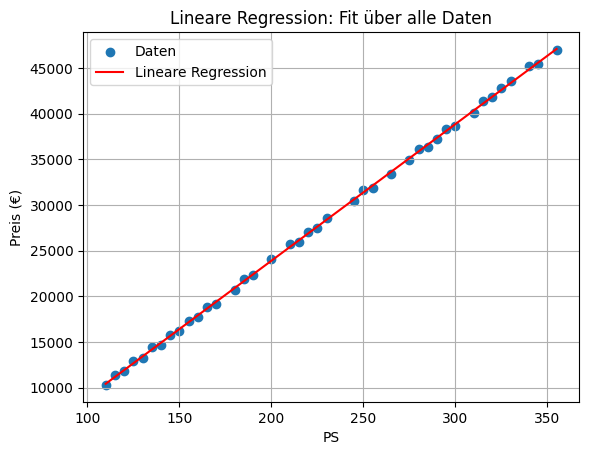

In [15]:
# Regressionsgerade über den gesamten Bereich
ps_grid = np.linspace(df["PS"].min(), df["PS"].max(), 200).reshape(-1, 1)
price_line = model.predict(ps_grid)

plt.figure()
plt.scatter(X_train, y_train, label="Daten")
plt.plot(ps_grid, price_line, label="Lineare Regression", color='red')
plt.xlabel("PS")
plt.ylabel("Preis (€)")
plt.title("Lineare Regression: Fit über alle Daten")
plt.legend()
plt.grid(True)
plt.show()

## Visualisierung 2: Testset – Ist vs. Prognose


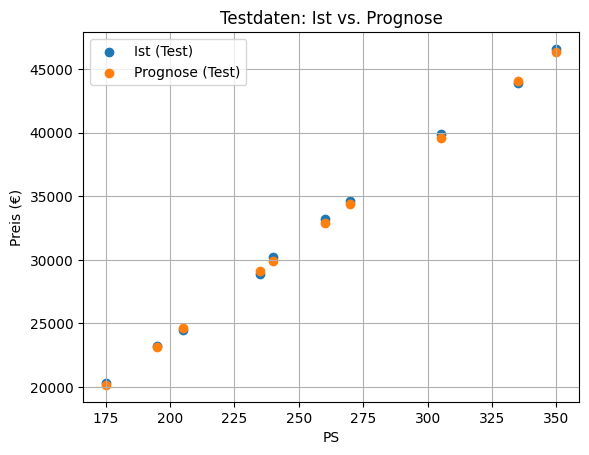

In [12]:
plt.figure()
plt.scatter(X_test["PS"], y_test, label="Ist (Test)")
plt.scatter(X_test["PS"], y_pred, label="Prognose (Test)")
plt.xlabel("PS")
plt.ylabel("Preis (€)")
plt.title("Testdaten: Ist vs. Prognose")
plt.legend()
plt.grid(True)
plt.show()


## Visualisierung 3: Fehlervisualisierung


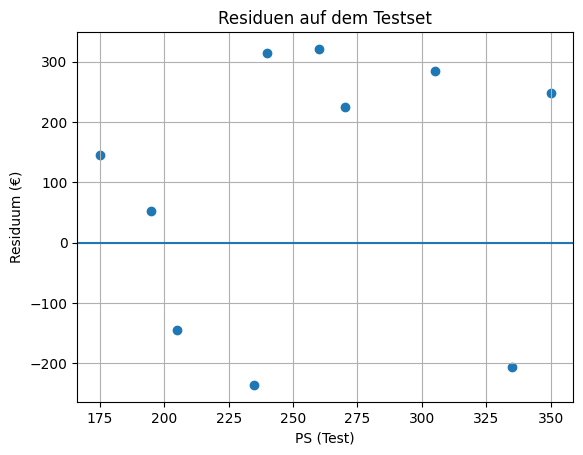

In [11]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(X_test["PS"], residuals)
plt.axhline(0)
plt.xlabel("PS (Test)")
plt.ylabel("Residuum (€)")
plt.title("Residuen auf dem Testset")
plt.grid(True)
plt.show()


## (Optional) Vorhersage für neue PS-Werte


In [10]:
# Beispiel: neue Werte vorhersagen
new_ps = pd.DataFrame({"PS": [150, 200, 275, 340]})
pred_prices = model.predict(new_ps)

pd.DataFrame({"PS": new_ps["PS"], "Preis_Prognose": np.round(pred_prices, 0).astype(int)})


,PS,Preis_Prognose
0,150,16411
1,200,23897
2,275,35124
3,340,44855
